<h3> The Perceptron </h3>

Today we will build a perceptron that will allow us to determine whether a patient has a sleep disorder or not. We will build it and train it from scratch using only the numpy library, with the additional support of pandas to load the data and matplotlib to visualize the training process and results.

<center>
    <figure>
    <img src="../1-perceptron/perceptron-diagram.png" alt="perceptron" width="75%"/>
      <figcaption>Schematic representation of a Perceptron</figcaption>
    </figure>
</center>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy._core.multiarray failed to import

**Exercise 1** - Load the data from the sleep_disorder_data.csv file with pandas and visualize it in the notebook.

In [2]:
# your code goes here

**Exercise 2** - Select the columns 'Quality of Sleep', 'Physical Activity Level' and 'Stress Level' as your input data `X` and the column 'Sleep Disorder' as your target `y`

In [3]:
# your code goes here

**Exercise 3** - You should see that you have three different labels: 'Sleep Apnea', 'Insomnia' and 'None'. The first two correspond to sleeping disorders, while the label 'None' refers to the absence of sleep disorder (normal sleep). Convert the labels to numerical values such that each 'None' becomes 0 and 'Sleep Apnea' and 'Insomnia' both become 1. Convert your numpy array to integer data type.

In [4]:
# your code goes here

**Exercise 4** - Standardize the data matrix `X` such that each element in the resulting matrix is the following:

\begin{equation}
x_i^j:=\frac{x_i^j-\mu^j}{\sigma^j},
\end{equation}

where $x_i^j$ is the $i$th data point in the $j$th column and $\mu_j$ and $\sigma_j$ are the mean and standard deviation, respectively, of the $j$th column (note that $\sigma_j$ refers to the standard deviation of column $j$ of the feature space and is not related to the sigmoid function $\sigma$)

In [5]:
# your code goes here

Now it is time to start building the model. Since the elements in the training set are 3 dimensional (we are looking at 3 features: Sleep Quality, Exercise and Stress Level) our single neuron model will have 3 weights and 1 bias.

**Exercise 5** - Initialize a matrix of random weights of shape (3,1) and a bias of shape (1,) between -1 and 1, store them in two variables called `weights` and `bias` and print them. Use the random seed 6 for reproducibility and use `np.random.uniform` and `np.random.rand` to initialize the parameters.

The next step is to define the forward function. The output is given by the weighted sum of the inputs plus the bias, which then goes through a sigmoid function to produce the final prediction $\hat{y}$:

\begin{equation}
\hat{y}=\sigma(w_1x_1+w_2x_2+w_3x_3+b)
\end{equation}

Given an input column vector $\vec{x}=\begin{bmatrix}x_1 \\ x_2 \\ x_3\end{bmatrix}$, a weight matrix $W=\begin{bmatrix}w_1 \\ w_2 \\ w_3\end{bmatrix}$ and a bias $b$ we can express the linear combination of the weights and inputs plus the bias in matrix form as

\begin{equation}
W^T\vec{x}+b=\begin{bmatrix}w_1 & w_2 & w_3\end{bmatrix}\begin{bmatrix}x_1 \\ x_2 \\ x_3\end{bmatrix}+b=w_1x_1+w_2x_2+w_3x_3+b
\end{equation}

which gives the following expression for the prediction:

\begin{equation}
\hat{y}=\sigma(W^T\vec{x}+b)
\end{equation}

In our case, since each column represents a feature and observations are represented by rows, we also need to transpose the input matrix `X`.

**Exercise 6** - Define a function called `sigmoid` that takes an input `x` and returns the following:

\begin{equation}
\sigma(x)=\frac{1}{1+e^{-x}}
\end{equation}

remember that you can use `np.exp(x)` to raise $e^x$

In [6]:
# your code goes here

**Exercise 7** - Define a function called `forward` that takes 3 inputs: the weights, the bias and the data matrix `X` and returns the output of the perceptron:

\begin{equation}
\hat{y}=\sigma(W^TX+b)
\end{equation}

Tip: use the previously defined `sigmoid` function.

In [7]:
# your code goes here

**Exercise 8** - Make an initial prediction with the untrained model using the `forward` function that you just defined. You should visualize two outputs: the plain output and the rounded output, which will be 1 or 0 for each data point. Compare your predictions with the target $y$. How many did you get right?

In [8]:
# your code goes here

**Exercise 9** - Define a function called `mse_loss` that calculates the mean squared error:

\begin{equation}
L=MSE=\frac{1}{n}\sum(y-\hat{y})^2
\end{equation}

In [9]:
# your code goes here

Before moving on to the final training loop, we need to define a function that updates the weights according to the value of the gradient, which gives us information about which direction we have to move in order to minimize the loss function. The derivative of the sigmoid function is $\sigma(z)'=\sigma(z)(1-\sigma(z))$ and the gradient of the loss function $L$ for some input vector $\vec{x}$ and target $y$ is given by 

\begin{equation}
\nabla L(x,y)=\begin{bmatrix}
           \frac{\partial L}{\partial w_1} \\
           \frac{\partial L}{\partial w_2} \\
           \frac{\partial L}{\partial w_3} \\
           \frac{\partial L}{\partial b} 
         \end{bmatrix}=s_L'\begin{bmatrix}
         x_1s \\
         x_2s \\
         x_3s \\
         1
         \end{bmatrix}
         \end{equation}
         
where $s_L'=-2\left[\left(1-\sigma(x)\right)\sigma(x)\right]\left[y-\sigma(x)\right]$

**Exercise 10** - Define a function called `compute_gradient` that takes as input the weights, bias, input data $X$ and target $y$ and returns the gradient of the loss function $L$ as a tuple: the first value is an array with three entries consisting of the derivative of the loss function with respect to each weight and the second value is the derivative of the loss function with respect to the bias.

In [10]:
# your code goes here

Finally, we need to define the training loop. At each step, we will use `X` as the input and `y` as the target that we will compare to the output, and we will update the weights such that the error decreases.

**Exercise 11** - Define a training loop with 30 epochs and learning rate $\alpha=0.1$. Use the previously defined `compute_gradient` function and update the weights accordingly. At each step, print the loss and store it in a list.

In [11]:
# your code goes here

**Exercise 12** - Plot the loss per epoch. Is the perceptron learning from the training data?

In [12]:
# your code goes here

**Exercise 13** - Print the final weights matrix and the bias. How do they compare with the initial weights and bias from exercise 4? Which features are positively correlated and which ones negatively correlated with the presence of a sleep disorder?

In [13]:
# your code goes here

**Exercise 14** - Make a final prediction with the trained model and compare it to the target $y$. How many of your predictions are correct? What is the accuracy of your model?

In [14]:
# your code goes here

<h2>Neural Networks</h2>

The dataset that we are going to use here is from https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset. Data is from the year 1988 from hospitals in Clevelant, Hungary, Switzerland and Long Beach V and are from patients that had been tested for potential cardiovascular diseases. We have information from 13 characteristics related to the patient's health and our goal is to try to predict whether a patinet is likely to suffer a cardiovascular disease or not.

**Exercise 1**

Read the dataset using pandas and show the first lines of data in the notebook

In [15]:
import pandas as pd

# your code goes here

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy._core.multiarray failed to import

<h5> Exercise 2 </h5>

Some dataset entries contain NaNs. Use pandas `.dropna` method to remove them. Then select the column 'target' and store it in a variable called `y` and the rest of the columns in a variable called `X`.

In [16]:
# your code goes here

<h5>Exercise 3<H5>

Use Sklearn's *train_test_split* function to split the dataset in train and test. The test set must be 20% of the total data. Save the inputs and labels in variables called `X_train`, `y_train`, `X_test` and `y_test`. Use the argument *stratify* to ensure that the ratio of positive (1) and negative(0) classes is equal in the train and test sets. Use `StandardScaler` from Sklearn to standardize the inputs with the training mean and standard deviation. You can do this by calling the `.fit_transform` method with the training set and just the `.transform` method with the test set. You can find the documentation in the following links:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# your code goes here

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy._core.multiarray failed to import

<h4>PyTorch </h4>

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader

OSError: [WinError 127] The specified procedure could not be found. Error loading "D:\conda\Lib\site-packages\torch\lib\torch_cuda.dll" or one of its dependencies.

To use PyTorch we need to transform the numpy arrays into torch tensors. We will also convert the labels into 2 dimensional tensors where the target 0 will become the tensor [1, 0] and the target 1 will become the tensor [0, 1]. Remember that each element in the train_set and test_set lists must be a tuple with two elements where the first element is the data tensor and the second one is the label tensor.

In [19]:
train_set, test_set = [], []
for X, y in zip(X_train, y_train):
    y_vector = torch.zeros(2)
    y_vector[int(y)] = 1
    train_set.append((torch.tensor(X, dtype=torch.float32), y_vector))
for X, y in zip(X_test, y_test):
    y_vector = torch.zeros(2)
    y_vector[int(y)] = 1
    test_set.append((torch.tensor(X, dtype=torch.float32), y_vector))

NameError: name 'X_train' is not defined

Exercise 4

Define the DataLoader for the train and test sets. Use a batch size of 16 for the train loader with `shuffle=True` and a batch size of 1 for the test loader with `shuffle=False`. Name the dataloader variables `train_loader` and `test_loader`. We will ignore PyTorch's Dataset class for now.

In [20]:
# your code goes here

<h5> Exercise 5 </h5>

Now we need to design the neural network. We will create a network with two *fully connected* layers: the first one receives 13 input features and has 16 *hidden neurons*, and the second one receives 16 input features and has 2 output neurons, one for each label that we want to predict. In the first layer we will use ReLU as the activation function and in the second one we will use softmax. The code to define each of the activation layers/functions is as follows:

*   `nn.Linear(n_inputs, n_outputs)` -> Fully connected layer with *n_inputs* input neurons and *n_outputs* output neurons. Store it as the following attribute: `self.linear = nn.Linear(n_inputs, n_outputs)` (remember that you should have `self.linear_1` and `self.linear_2` in the constructor).
*   `F.relu(x)` -> Applies the ReLU function ($max(0,x_i)$) to the input tensor. It returns a tensor with the same shape as the input such that if the input is a tensor with values [-2, -1, 0, 1, 2] the output is the tensor [0, 0, 0, 1, 2].
*   `F.softmax(x, dim=1)` -> It applies the softmax function to the input tensor along dimension 1, such that the sum of the output of all neurons is 1. As in the previous case, the shape of the output is the same as the shape of the input tensor.
*   We will apply the activation functions directly to the outputs of each layer. In the forward function, start with the input tensor `x` and apply the transformations until you reach the output in the following way:

    ```x = self.linear(x)```

    ```x = F.relu(x)```

    ```...```

Finally `return x`



In [21]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        # your code goes here
        pass

    def forward(self, x):
        # your code goes here
        return x

NameError: name 'nn' is not defined

To utilize the GPU in PyTorch we use the `.to()` method. It accepts as argument a string that can either be `'cuda'` (GPU) or `'cpu'`. Here we check if a GPU is available, otherwise we use the CPU. For this particular model and dataset which are relatively small it is viable to use the CPU, but it is generally recommended to use the GPU for training when possible.

In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = NeuralNetwork().to(device)

NameError: name 'torch' is not defined

Without executing the following cell, can you calculate the number of trainable parameters in your model? Check if your answer is correct:

In [23]:
print(sum(p.numel() for p in model.parameters()))

NameError: name 'model' is not defined

As loss function we will use the cross entropy, suitable for the current classification problem. As optimizer we will use the Adam with learning rate 5e-4.

https://machinelearningmastery.com/adam-optimization-algorithm-for-deep-learning/

In [24]:
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=5e-4)

NameError: name 'nn' is not defined

We finally define the training loop. We will train the model for 50 epochs and we will store the training loss, test loss and test accuracy per epoch in three separate lists.

In [25]:
epochs = 50
n_samples_train = len(train_loader)
n_samples_test = len(test_loader)
training_loss_per_epoch, test_loss_per_epoch, test_accuracy_per_epoch = [], [], []
for epoch in range(epochs):
    training_loss = 0
    for data, labels in train_loader:
        predict = model(data.to(device))
        loss = loss_function(labels.to(device), predict)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        training_loss += (loss.item() / n_samples_train)
    test_loss, correct, total = (0, 0, 0)
    for data, label in test_loader:
        predict = model(data.to(device))
        loss = loss_function(label.to(device), predict)
        test_loss += (loss.item() / n_samples_test)
        if torch.argmax(predict) == torch.argmax(label):
            correct += 1
        total += 1
    accuracy = correct/total*100
    training_loss_per_epoch.append(training_loss)
    test_loss_per_epoch.append(test_loss)
    test_accuracy_per_epoch.append(accuracy)
    print('training loss: {:.3f}, test loss: {:.3f}, test accuracy: {:.2f}%'.format(training_loss, test_loss, accuracy))

NameError: name 'train_loader' is not defined

What is the accuracy in the test set?

<h5> Exercise 6 </h5>

Create a plot with two subplots using the following code:

```fig, ax = plt.subplots(1,2,figsize=(12,5))```

In the first subplot, plot the training and test curves per epoch, label them 'train' and 'test' and show the legend. Plot the accuracy per epoch in the second subplot in green. Name the y_label `Loss` in the first subplot, `Accuracy %` in the second subplot and the x_label `Epoch` in both subplots using a font size of 16.

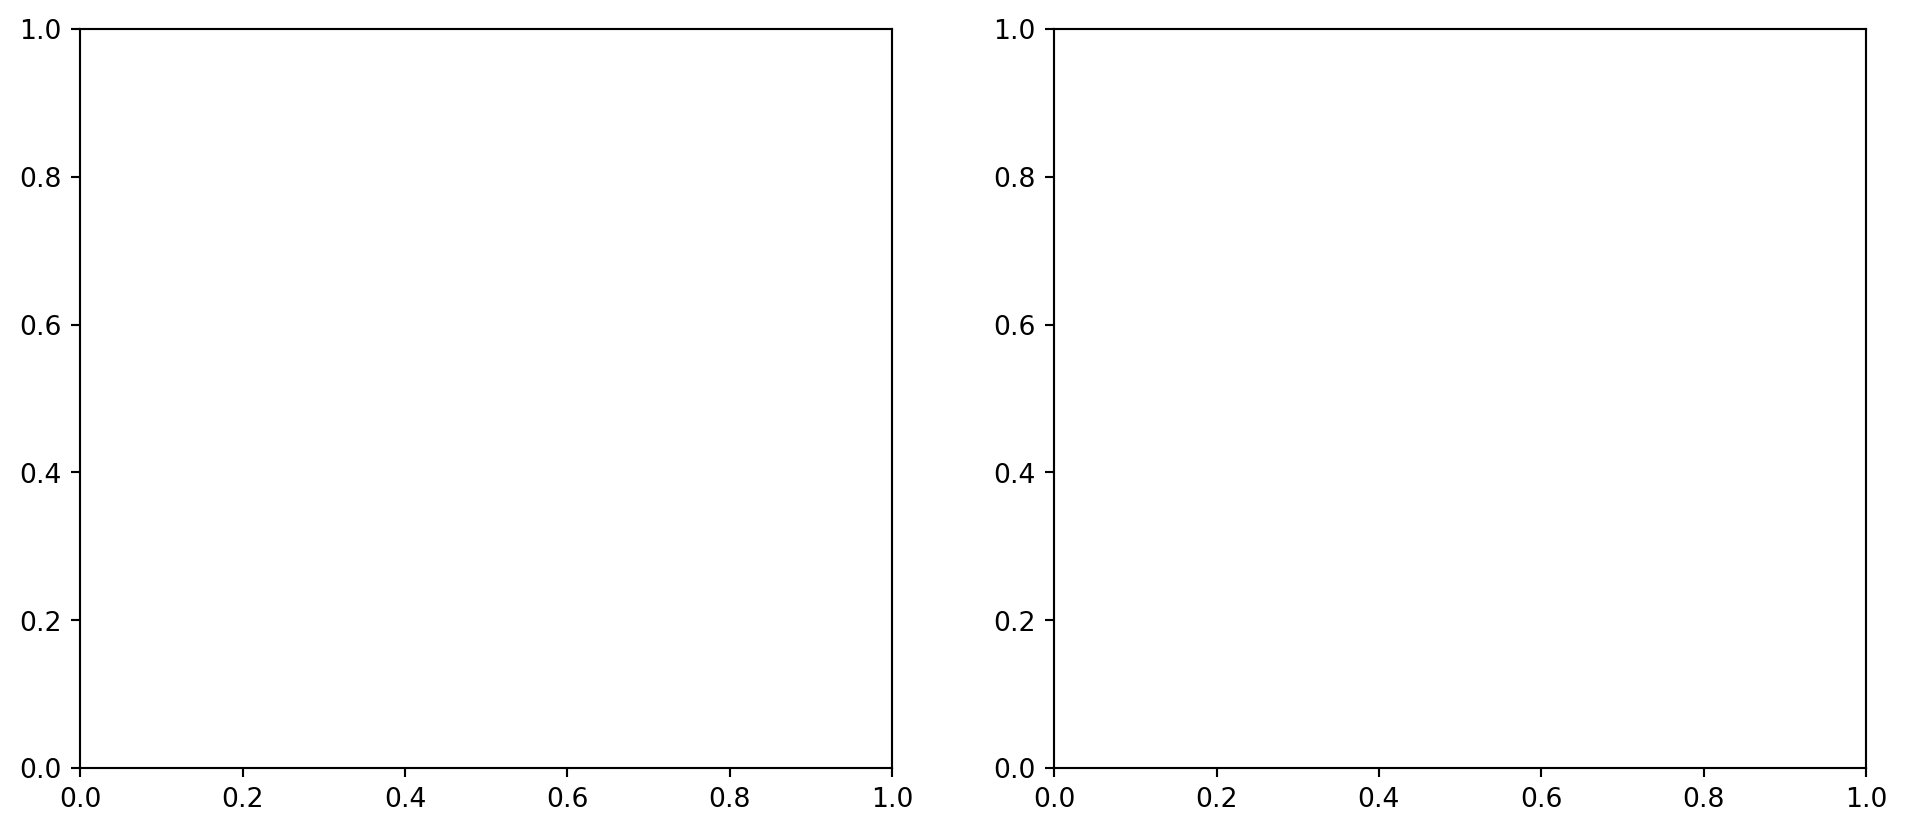

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(12, 5))
# your code goes here
